# Model Improvement 3 — XGBoost

In [21]:
%pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Preparation

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np

project_dir = Path(r"C:\PROJECTS\FUTURE_ML_01")

daily_sales = pd.read_csv(
    project_dir / "data" / "processed" / "daily_sales_model_data.csv",
    parse_dates=["date"]
)

daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

data = daily_sales.copy()

data["lag_3"] = data["total_sales"].shift(3)
data["lag_5"] = data["total_sales"].shift(5)
data["lag_21"] = data["total_sales"].shift(21)
data["lag_28"] = data["total_sales"].shift(28)

previous_sales = data["total_sales"].shift(1)

data["rolling_mean_3"] = previous_sales.rolling(3).mean()
data["rolling_mean_7"] = previous_sales.rolling(7).mean()
data["rolling_mean_14"] = previous_sales.rolling(14).mean()
data["rolling_mean_30"] = previous_sales.rolling(30).mean()

data["rolling_std_7"] = previous_sales.rolling(7).std()
data["rolling_std_14"] = previous_sales.rolling(14).std()

data["ewm_7"] = previous_sales.ewm(span=7, adjust=False).mean()
data["ewm_14"] = previous_sales.ewm(span=14, adjust=False).mean()

data = data.dropna().reset_index(drop=True)

features_xgb = [
    "year",
    "month",
    "quarter",
    "day",
    "day_of_week_num",
    "is_weekend",
    "lag_1",
    "lag_3",
    "lag_5",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_30",
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_14",
    "ewm_7",
    "ewm_14"
]

split_date_xgb = "2016-07-01"

train_xgb = data[data["date"] < split_date_xgb].copy()
validation_xgb = data[data["date"] >= split_date_xgb].copy()

X_train_xgb = train_xgb[features_xgb]
y_train_xgb = train_xgb["total_sales"]

X_validation_xgb = validation_xgb[features_xgb]
y_validation_xgb = validation_xgb["total_sales"]

print("Training shape:", X_train_xgb.shape)
print("Validation shape:", X_validation_xgb.shape)

Training shape: (1214, 22)
Validation shape: (410, 22)


## Train XGBoost Model

In [23]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_predictions = xgb_model.predict(X_validation_xgb)

mae_xgb = mean_absolute_error(y_validation_xgb, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_validation_xgb, xgb_predictions))

non_zero_actual = y_validation_xgb != 0

mape_xgb = np.mean(
    np.abs(
        (y_validation_xgb[non_zero_actual] -
         xgb_predictions[non_zero_actual])
        / y_validation_xgb[non_zero_actual]
    )
) * 100

print(f"XGBoost MAE: {mae_xgb:,.2f}")
print(f"XGBoost RMSE: {rmse_xgb:,.2f}")
print(f"XGBoost MAPE: {mape_xgb:.2f}%")

XGBoost MAE: 67,607.60
XGBoost RMSE: 105,464.50
XGBoost MAPE: 24.64%


## Tune XGBoost

In [24]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_xgb, y_train_xgb)

best_xgb = xgb_search.best_estimator_

print("Best parameters:")
print(xgb_search.best_params_)

Best parameters:
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


## Evaluate Tuned XGBoost

In [25]:
tuned_xgb_predictions = best_xgb.predict(X_validation_xgb)

mae_tuned_xgb = mean_absolute_error(
    y_validation_xgb,
    tuned_xgb_predictions
)

rmse_tuned_xgb = np.sqrt(
    mean_squared_error(
        y_validation_xgb,
        tuned_xgb_predictions
    )
)

non_zero_actual = y_validation_xgb != 0

mape_tuned_xgb = np.mean(
    np.abs(
        (y_validation_xgb[non_zero_actual] -
         tuned_xgb_predictions[non_zero_actual])
        / y_validation_xgb[non_zero_actual]
    )
) * 100

print(f"Tuned XGBoost MAE: {mae_tuned_xgb:,.2f}")
print(f"Tuned XGBoost RMSE: {rmse_tuned_xgb:,.2f}")
print(f"Tuned XGBoost MAPE: {mape_tuned_xgb:.2f}%")

Tuned XGBoost MAE: 77,764.03
Tuned XGBoost RMSE: 114,031.17
Tuned XGBoost MAPE: 25.44%


## Compare All Models

In [26]:
all_models_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Improved Random Forest",
        "HistGradientBoosting",
        "Tuned HistGradientBoosting",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        76821.42,
        70350.96,
        75580.38,
        82841.34,
        mae_xgb,
        mae_tuned_xgb
    ],
    "RMSE": [
        133556.96,
        110149.09,
        113794.55,
        119229.88,
        rmse_xgb,
        rmse_tuned_xgb
    ],
    "MAPE": [
        47.50,
        28.28,
        27.77,
        26.69,
        mape_xgb,
        mape_tuned_xgb
    ]
})

display(all_models_comparison.round(2))

,Model,MAE,RMSE,MAPE
0,Baseline Random Forest,76821.42,133556.96,47.50
1,Improved Random Forest,70350.96,110149.09,28.28
2,HistGradientBoosting,75580.38,113794.55,27.77
3,Tuned HistGradientBoosting,82841.34,119229.88,26.69
4,XGBoost,67607.60,105464.50,24.64
5,Tuned XGBoost,77764.03,114031.17,25.44


In [27]:
from pathlib import Path
import joblib

project_dir = Path(r"C:\PROJECTS\FUTURE_ML_01")

models_dir = project_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    xgb_model,
    models_dir / "xgboost_model.joblib"
)

joblib.dump(
    features_xgb,
    models_dir / "xgboost_features.joblib"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


## Save XGBoost Model Performance

In [28]:
output_dir = project_dir / "outputs_xgboost"
output_dir.mkdir(parents=True, exist_ok=True)

model_performance = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae_xgb],
    "RMSE": [rmse_xgb],
    "MAPE": [mape_xgb]
})

model_performance.to_csv(
    output_dir / "model_performance.csv",
    index=False
)

print("model_performance.csv saved successfully.")

model_performance.csv saved successfully.


## XGBoost Feature Importance

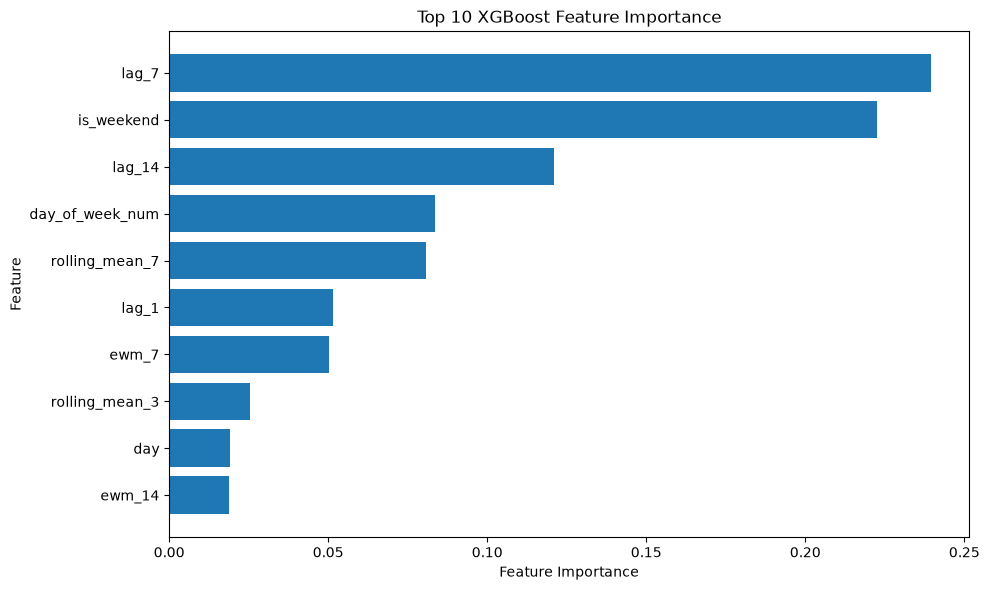

Feature importance analysis saved successfully.

Top 10 features:
        Feature  Importance  Importance_Percentage
          lag_7    0.239589              23.958941
     is_weekend    0.222453              22.245325
         lag_14    0.121007              12.100663
day_of_week_num    0.083493               8.349341
 rolling_mean_7    0.080681               8.068089
          lag_1    0.051544               5.154420
          ewm_7    0.050141               5.014149
 rolling_mean_3    0.025447               2.544650
            day    0.019133               1.913317
         ewm_14    0.018941               1.894149


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

output_dir = project_dir / "outputs_xgboost"
figures_dir = output_dir / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

feature_importance = pd.DataFrame({
    "Feature": features_xgb,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance["Importance_Percentage"] = (
    feature_importance["Importance"]
    / feature_importance["Importance"].sum()
) * 100

feature_importance.to_csv(
    output_dir / "feature_importance.csv",
    index=False
)

top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importance")
plt.tight_layout()

plt.savefig(
    figures_dir / "xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance analysis saved successfully.")
print("\nTop 10 features:")
print(
    feature_importance[
        ["Feature", "Importance", "Importance_Percentage"]
    ].head(10).to_string(index=False)
)

## XGBoost Actual vs Predicted

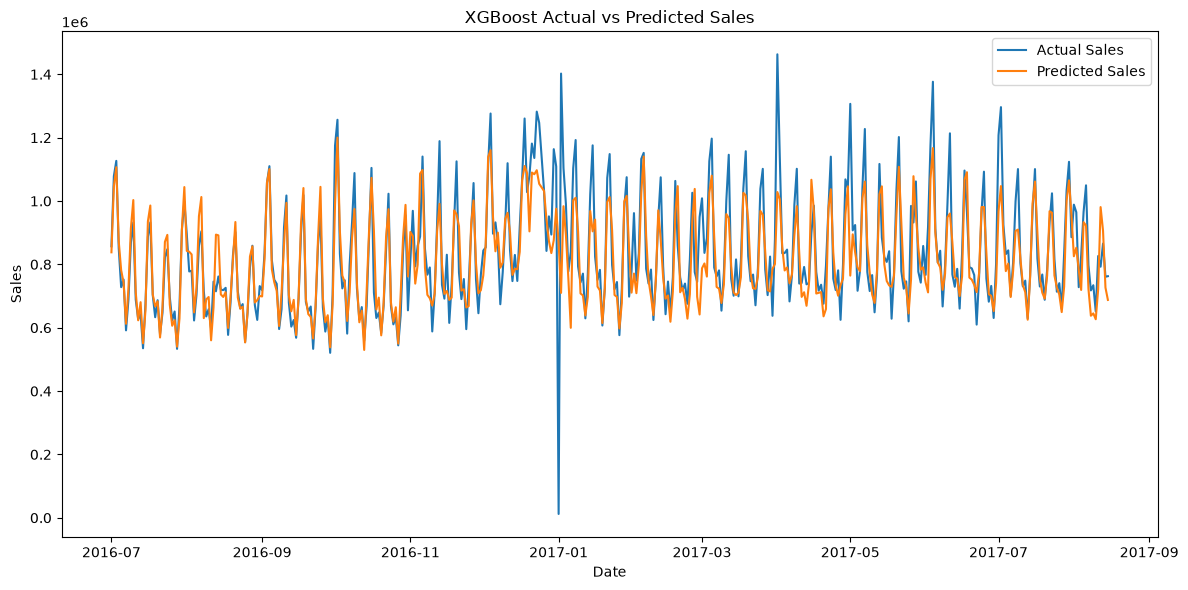

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    validation_xgb["date"],
    y_validation_xgb,
    label="Actual Sales"
)

plt.plot(
    validation_xgb["date"],
    xgb_predictions,
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("XGBoost Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()

plt.savefig(
    project_dir / "outputs_xgboost" / "figures" / "xgboost_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## XGBoost Prediction Errors

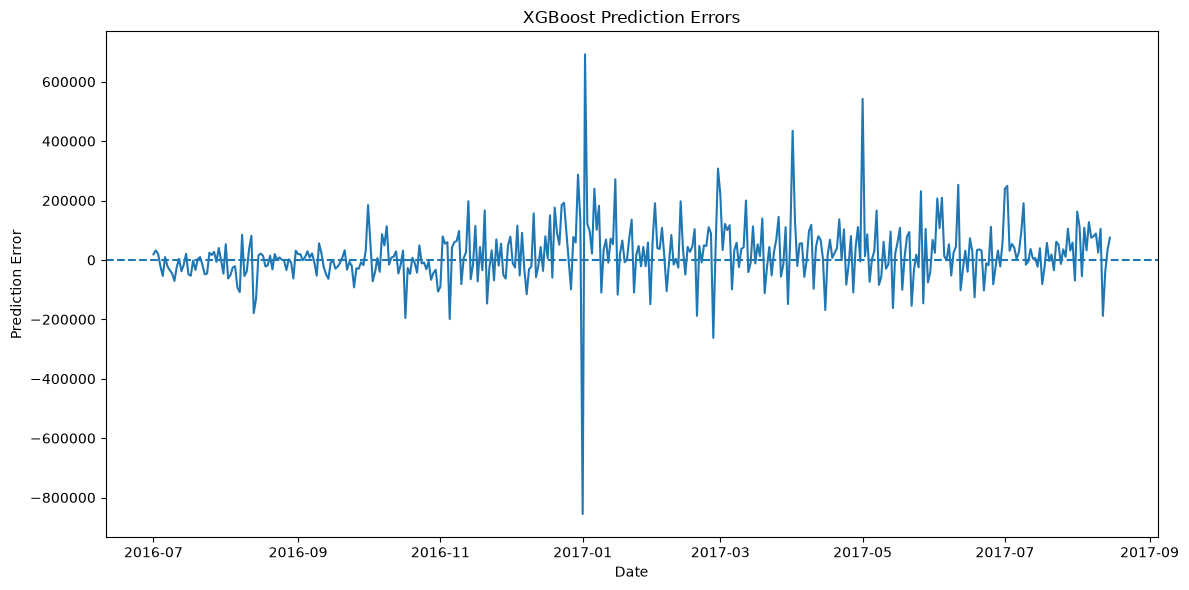

In [31]:
import matplotlib.pyplot as plt

prediction_errors = y_validation_xgb - xgb_predictions

plt.figure(figsize=(12, 6))

plt.plot(
    validation_xgb["date"],
    prediction_errors
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.title("XGBoost Prediction Errors")
plt.tight_layout()

plt.savefig(
    project_dir / "outputs_xgboost" / "figures" / "xgboost_prediction_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## XGBoost Business Insights

In [35]:
import pandas as pd

output_dir = project_dir / "outputs_xgboost"
output_dir.mkdir(parents=True, exist_ok=True)

average_actual = y_validation_xgb.mean()
average_predicted = xgb_predictions.mean()

mae_percentage = (mae_xgb / average_actual) * 100
rmse_percentage = (rmse_xgb / average_actual) * 100

business_insights = pd.DataFrame({
    "Insight": [
        "Selected Model",
        "Validation Period",
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "Mean Absolute Percentage Error",
        "Average Actual Daily Sales",
        "Average Predicted Daily Sales",
        "MAE as Percentage of Average Sales",
        "Maximum Actual Daily Sales",
        "Maximum Predicted Daily Sales"
    ],
    "Value": [
        "XGBoost",
        f"{validation_xgb['date'].min().date()} to {validation_xgb['date'].max().date()}",
        round(mae_xgb, 2),
        round(rmse_xgb, 2),
        round(mape_xgb, 2),
        round(average_actual, 2),
        round(average_predicted, 2),
        round(mae_percentage, 2),
        round(y_validation_xgb.max(), 2),
        round(xgb_predictions.max(), 2)
    ]
})

business_insights.to_csv(
    output_dir / "business_insights.csv",
    index=False
)

print("Business insights saved successfully.")

Business insights saved successfully.


## Save XGBoost 30-Day Forecast

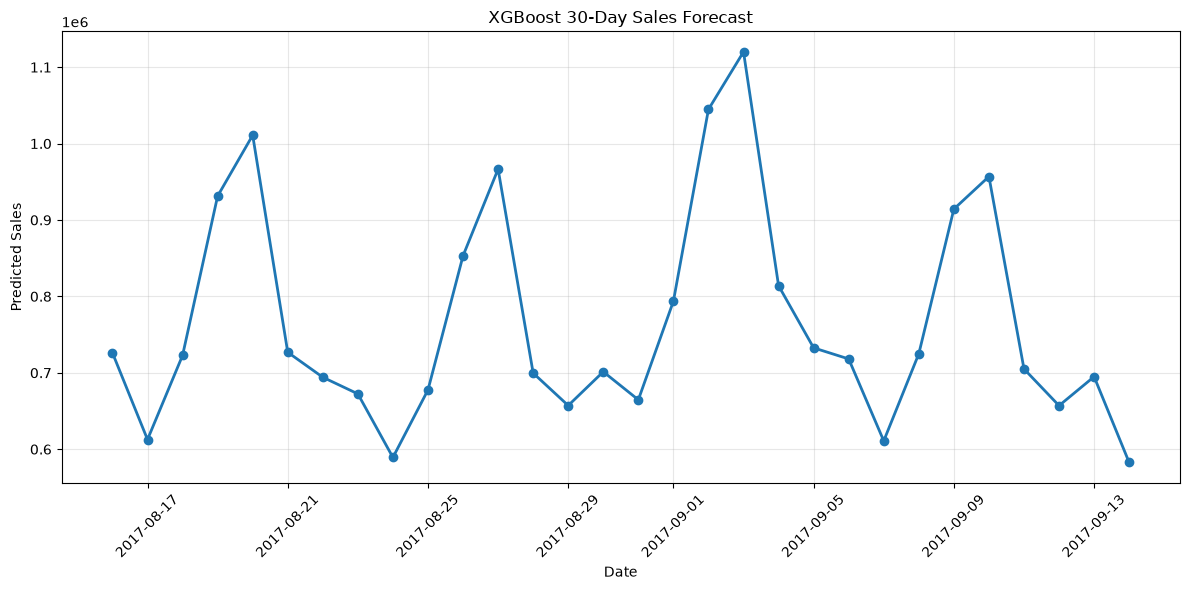

30-day XGBoost forecast generated successfully.
Forecast period: 2017-08-16 to 2017-09-14
Average forecast sales: 765,879.12
Maximum forecast sales: 1,120,033.75
Minimum forecast sales: 582,604.69


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

output_dir = project_dir / "outputs_xgboost"
figures_dir = output_dir / "figures"
forecasts_dir = output_dir / "forecasts"

figures_dir.mkdir(parents=True, exist_ok=True)
forecasts_dir.mkdir(parents=True, exist_ok=True)

forecast_data = data[["date", "total_sales"]].copy()
forecast_values = []

last_date = forecast_data["date"].max()

for i in range(1, 31):

    future_date = last_date + pd.Timedelta(days=i)
    previous_sales = forecast_data["total_sales"]

    input_data = pd.DataFrame([{
        "year": future_date.year,
        "month": future_date.month,
        "quarter": future_date.quarter,
        "day": future_date.day,
        "day_of_week_num": future_date.dayofweek,
        "is_weekend": int(future_date.dayofweek >= 5),

        "lag_1": previous_sales.iloc[-1],
        "lag_3": previous_sales.iloc[-3],
        "lag_5": previous_sales.iloc[-5],
        "lag_7": previous_sales.iloc[-7],
        "lag_14": previous_sales.iloc[-14],
        "lag_21": previous_sales.iloc[-21],
        "lag_28": previous_sales.iloc[-28],
        "lag_30": previous_sales.iloc[-30],

        "rolling_mean_3": previous_sales.tail(3).mean(),
        "rolling_mean_7": previous_sales.tail(7).mean(),
        "rolling_mean_14": previous_sales.tail(14).mean(),
        "rolling_mean_30": previous_sales.tail(30).mean(),

        "rolling_std_7": previous_sales.tail(7).std(),
        "rolling_std_14": previous_sales.tail(14).std(),

        "ewm_7": previous_sales.ewm(
            span=7,
            adjust=False
        ).mean().iloc[-1],

        "ewm_14": previous_sales.ewm(
            span=14,
            adjust=False
        ).mean().iloc[-1]
    }])

    prediction = xgb_model.predict(
        input_data[features_xgb]
    )[0]

    prediction = max(0, prediction)

    forecast_values.append({
        "date": future_date,
        "predicted_sales": prediction
    })

    forecast_data = pd.concat(
        [
            forecast_data,
            pd.DataFrame([{
                "date": future_date,
                "total_sales": prediction
            }])
        ],
        ignore_index=True
    )

forecast_30_days = pd.DataFrame(forecast_values)

forecast_30_days.to_csv(
    forecasts_dir / "30_day_sales_forecast.csv",
    index=False
)

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_30_days["date"],
    forecast_30_days["predicted_sales"],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.title("XGBoost 30-Day Sales Forecast")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "xgboost_future_30_day_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("30-day XGBoost forecast generated successfully.")
print(f"Forecast period: {forecast_30_days['date'].min().date()} to {forecast_30_days['date'].max().date()}")
print(f"Average forecast sales: {forecast_30_days['predicted_sales'].mean():,.2f}")
print(f"Maximum forecast sales: {forecast_30_days['predicted_sales'].max():,.2f}")
print(f"Minimum forecast sales: {forecast_30_days['predicted_sales'].min():,.2f}")

## Verify XGBoost Output Files

In [38]:
from pathlib import Path

output_dir = project_dir / "outputs_xgboost"

required_files = [
    output_dir / "model_performance.csv",
    output_dir / "feature_importance.csv",
    output_dir / "business_insights.csv",
    output_dir / "figures" / "xgboost_feature_importance.png",
    output_dir / "figures" / "xgboost_actual_vs_predicted.png",
    output_dir / "figures" / "xgboost_prediction_errors.png",
    output_dir / "figures" / "xgboost_future_30_day_forecast.png",
    output_dir / "forecasts" / "30_day_sales_forecast.csv"
]

for file in required_files:
    status = "✓" if file.exists() else "✗"
    print(f"{status} {file.relative_to(project_dir)}")

✓ outputs_xgboost\model_performance.csv
✓ outputs_xgboost\feature_importance.csv
✓ outputs_xgboost\business_insights.csv
✓ outputs_xgboost\figures\xgboost_feature_importance.png
✓ outputs_xgboost\figures\xgboost_actual_vs_predicted.png
✓ outputs_xgboost\figures\xgboost_prediction_errors.png
✓ outputs_xgboost\figures\xgboost_future_30_day_forecast.png
✓ outputs_xgboost\forecasts\30_day_sales_forecast.csv


## Verify XGBoost CSV Outputs

In [39]:
import pandas as pd

output_dir = project_dir / "outputs_xgboost"

model_performance = pd.read_csv(
    output_dir / "model_performance.csv"
)

feature_importance = pd.read_csv(
    output_dir / "feature_importance.csv"
)

business_insights = pd.read_csv(
    output_dir / "business_insights.csv"
)

print("Model Performance:")
print(model_performance)

print("\nTop 10 Features:")
print(feature_importance.head(10))

print("\nBusiness Insights:")
print(business_insights)

Model Performance:
     Model           MAE           RMSE       MAPE
0  XGBoost  67607.597303  105464.503649  24.635908

Top 10 Features:
           Feature  Importance  Importance_Percentage
0            lag_7    0.239589              23.958940
1       is_weekend    0.222453              22.245325
2           lag_14    0.121007              12.100663
3  day_of_week_num    0.083493               8.349341
4   rolling_mean_7    0.080681               8.068089
5            lag_1    0.051544               5.154420
6            ewm_7    0.050141               5.014149
7   rolling_mean_3    0.025447               2.544650
8              day    0.019133               1.913317
9           ewm_14    0.018941               1.894149

Business Insights:
                              Insight                     Value
0                      Selected Model                   XGBoost
1                   Validation Period  2016-07-01 to 2017-08-15
2                 Mean Absolute Error                  

## Final Model Comparison

In [40]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Improved Random Forest",
        "HistGradientBoosting",
        "Tuned HistGradientBoosting",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        76821.42,
        70350.96,
        75580.38,
        82841.34,
        67607.60,
        77764.03
    ],
    "RMSE": [
        133556.96,
        110149.09,
        113794.55,
        119229.88,
        105464.50,
        114031.17
    ],
    "MAPE": [
        47.50,
        28.28,
        27.77,
        26.69,
        24.64,
        25.44
    ]
})

final_comparison = final_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

print(final_comparison)

final_comparison.to_csv(
    project_dir / "outputs_xgboost" / "final_model_comparison.csv",
    index=False
)

print("\nFinal model comparison saved successfully.")

                        Model       MAE       RMSE   MAPE
0                     XGBoost  67607.60  105464.50  24.64
1      Improved Random Forest  70350.96  110149.09  28.28
2        HistGradientBoosting  75580.38  113794.55  27.77
3      Baseline Random Forest  76821.42  133556.96  47.50
4               Tuned XGBoost  77764.03  114031.17  25.44
5  Tuned HistGradientBoosting  82841.34  119229.88  26.69

Final model comparison saved successfully.


## Final XGBoost Model Summary

In [41]:
import pandas as pd

output_dir = project_dir / "outputs_xgboost"

final_summary = pd.DataFrame({
    "Metric": [
        "Selected Model",
        "MAE",
        "RMSE",
        "MAPE",
        "Validation Period",
        "Average Actual Daily Sales",
        "Average Predicted Daily Sales",
        "MAE as Percentage of Average Sales"
    ],
    "Value": [
        "XGBoost",
        round(mae_xgb, 2),
        round(rmse_xgb, 2),
        round(mape_xgb, 2),
        f"{validation_xgb['date'].min().date()} to {validation_xgb['date'].max().date()}",
        round(y_validation_xgb.mean(), 2),
        round(xgb_predictions.mean(), 2),
        round((mae_xgb / y_validation_xgb.mean()) * 100, 2)
    ]
})

final_summary.to_csv(
    output_dir / "final_xgboost_summary.csv",
    index=False
)

print(final_summary.to_string(index=False))
print("\nFinal XGBoost summary saved successfully.")

                            Metric                    Value
                    Selected Model                  XGBoost
                               MAE                  67607.6
                              RMSE                 105464.5
                              MAPE                    24.64
                 Validation Period 2016-07-01 to 2017-08-15
        Average Actual Daily Sales                831372.98
     Average Predicted Daily Sales              811621.9375
MAE as Percentage of Average Sales                     8.13

Final XGBoost summary saved successfully.
